In [14]:
import importlib

import workflow.router
import workflow.task
import workflow.graph
import agents.coordinator


importlib.reload(workflow.router)
importlib.reload(workflow.task)
importlib.reload(agents.coordinator)
importlib.reload(workflow.graph)


from workflow.graph import AgentWorkflow


workflow = AgentWorkflow()

app = workflow.compile()


print("Workflow编译完成")

Workflow编译完成


In [23]:
state={
    "query":"设计Unity背包系统并生成代码并检查",
    
    "current_agent":"",
    
    "tasks":[],
    
    "agent_history":[],
    
    "requirements":[],
    
    "context":[],
    
    "architecture":"",
    
    "code":"",
    
    "review":{},
    
    "tools":[],
    
    "tokens":0,

    "repair_count":0
}

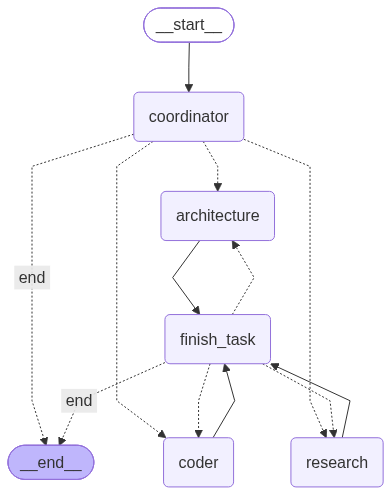

In [9]:
from IPython.display import Image,display


display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [10]:
from tools.file_tool import read_file,write_file

test_path="test.cs"


write_file(
    test_path,
    "public class Test{}"
)


content=read_file(test_path)


content

'public class Test{}'

In [11]:
from tools.code_tool import append_code


code="""
class Player
{

}
"""


new_code="""
void Move()
{

}
"""


result=append_code(
    code,
    new_code
)


print(result)


class Player
{

}


void Move()
{

}



In [13]:
# 测试 Coder Agent
from agents.coder import CoderAgent


coder = CoderAgent()


result = coder.run(state)

result

print(result["code"])

[Coder Agent]开始执行
[Coder Agent]文件修改完成
public class Test
{

}
// AI Agent生成代码
// AI Agent生成代码


In [33]:
import importlib

import agents.reviewer
import agents.coordinator
import workflow.graph

importlib.reload(agents.reviewer)
importlib.reload(agents.coordinator)
importlib.reload(workflow.graph)


from workflow.graph import AgentWorkflow


workflow = AgentWorkflow()

app = workflow.compile()


print("Workflow编译完成")

Workflow编译完成


In [7]:
result = app.invoke(state)

[Coordinator]任务规划:['architecture', 'coder', 'reviewer']
[Router]任务队列:['architecture', 'coder', 'reviewer']
[Architecture Agent]开始执行
[Finish Task]完成:architecture
[Finish Task]剩余任务:['coder', 'reviewer']
[Router]任务队列:['coder', 'reviewer']
[Coder Agent]开始执行
[Coder Agent]文件修改完成
[Finish Task]完成:coder
[Finish Task]剩余任务:['reviewer']
[Router]任务队列:['reviewer']
[Reviewer Agent]开始执行
[Reviewer Agent]评分:100
[Review Router]评分:100,修复次数:1
[Finish Task]完成:reviewer
[Finish Task]剩余任务:[]
[Router]任务队列:[]


In [2]:
import importlib

import agents.reviewer
import agents.coder
import workflow.review_router
import workflow.graph


importlib.reload(agents.reviewer)
importlib.reload(agents.coder)
importlib.reload(workflow.review_router)
importlib.reload(workflow.graph)


from workflow.graph import AgentWorkflow


workflow = AgentWorkflow()

app = workflow.compile()


print("Workflow编译完成")

Workflow编译完成


In [5]:
state={

    "query":"设计Unity背包系统并生成代码并检查",

    "current_agent":"",

    "tasks":[],

    "agent_history":[],

    "requirements":[],

    "context":[],

    "architecture":"",

    "code":"",

    "review":{},

    "tools":[],

    "tokens":0,

    "repair_count":0
}

In [3]:
from agents import reviewer

dir(reviewer)

['ReviewerAgent',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'check_code']

In [6]:
result = app.invoke(state)

result

[Coordinator]任务规划:['architecture', 'coder', 'reviewer']
[Router]任务队列:['architecture', 'coder', 'reviewer']
[Architecture Agent]开始执行
[Finish Task]完成:architecture
[Finish Task]剩余任务:['coder', 'reviewer']
[Router]任务队列:['coder', 'reviewer']
[Coder Agent]开始执行
[Coder Agent]文件修改完成
[Finish Task]完成:coder
[Finish Task]剩余任务:['reviewer']
[Router]任务队列:['reviewer']
[Reviewer Agent]开始执行
[Reviewer Agent]评分:100
[Review Router]评分:100,修复次数:1
[Finish Task]完成:reviewer
[Finish Task]剩余任务:[]
[Router]任务队列:[]


{'query': '设计Unity背包系统并生成代码并检查',
 'current_agent': 'reviewer',
 'tasks': [],
 'agent_history': ["任务规划:['architecture', 'coder', 'reviewer']",
  'Architecture Agent完成',
  'Coder Agent完成代码修改',
  'Reviewer Agent完成'],
 'requirements': [],
 'context': [],
 'architecture': 'Unity背包系统架构设计完成',
 'code': 'public class Test\n{\n\n}\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码\n// AI Agent生成代码',
 'review': {'score': 100, 'issues': [], 'pass': True},
 'tools': [],
 'tokens': 0,
 'repair_count': 1}

In [9]:
from dotenv import load_dotenv

load_dotenv()


from llm.deepseek import DeepSeekLLM


llm = DeepSeekLLM()


result = llm.invoke(
    "介绍一下Unity ECS架构"
)


print(result)

Unity ECS（Entity Component System）是 Unity 官方推出的一种**面向数据设计**的架构模式，旨在替代传统的面向对象（GameObject + MonoBehaviour）方案，以充分利用现代多核 CPU 的并行计算能力，提升大规模实体场景的性能。

---

## 一、核心概念：三个基本元素

### 1. **Entity（实体）**
- 只是一个 **ID**（通常是一个整数索引），本身不包含任何数据或行为。
- 可以理解为“容器”或“标签”，用于标识一个游戏对象。
- 例如：一个敌人、一颗子弹、一个粒子。

### 2. **Component（组件）**
- 纯**数据**结构，不包含方法（逻辑）。
- 例如：`Position`、`Velocity`、`Health`、`RenderMesh`。
- 所有组件被连续存储在内存的 **Archetype Chunk** 中，实现缓存友好。

### 3. **System（系统）**
- 包含**逻辑**，负责处理拥有特定组件组合的 Entity。
- 系统会遍历所有匹配的 Entity，读取/修改其组件数据。
- 系统可以并行执行（Job System），充分利用多核。

---

## 二、与传统 GameObject 的对比

| 特性 | GameObject + MonoBehaviour | ECS |
|------|---------------------------|-----|
| 数据存储 | 分散在堆上，每个对象独立 | 连续数组（Chunk），缓存友好 |
| 逻辑执行 | 单线程或简单协程 | 多线程 Job System |
| 对象数量 | 几千个可能卡顿 | 数十万甚至百万级 |
| 代码组织 | 继承、多态 | 组合、数据驱动 |
| 调试难度 | 相对容易 | 需要理解数据流和并行 |

---

## 三、ECS 架构的工作流程

1. **定义组件**（struct 实现 `IComponentData`）
2. **创建 Entity**（通过 `EntityManager` 或 `Archetype`）
3. **编写 System**（继承 `SystemBase` 或 `ISystem`）
4. **系统调度**：Uni

In [10]:
from agents.architecture import ArchitectureAgent


agent = ArchitectureAgent()


result = agent.run(state)


print(
    result["architecture"]
)

[Architecture Agent]开始执行
# Unity背包系统架构设计

## 一、系统架构总览

```
┌─────────────────────────────────────────────────────────────┐
│                    背包系统架构总览                          │
├─────────────────────────────────────────────────────────────┤
│  ┌─────────────┐  ┌─────────────┐  ┌─────────────┐        │
│  │  数据层      │  │  逻辑层      │  │  表现层      │        │
│  │  Inventory   │  │  Inventory  │  │  Inventory   │        │
│  │  Data        │  │  Manager    │  │  View        │        │
│  └──────┬──────┘  └──────┬──────┘  └──────┬──────┘        │
│         │                │                │                │
│         └────────────────┴────────────────┘                │
│                           │                                 │
│                    ┌──────┴──────┐                          │
│                    │  事件系统     │                          │
│                    └─────────────┘                          │
└─────────────────────────────────────────────────────────────┘
```


In [14]:
import importlib

import prompts.coder_prompt
import agents.coder


importlib.reload(
    prompts.coder_prompt
)

importlib.reload(
    agents.coder
)


from agents.coder import CoderAgent


coder = CoderAgent()


result = coder.run(state)


print(result["code"])

[Coder Agent]开始执行
[Coder Agent]DeepSeek代码生成完成
using System;
using System.Collections.Generic;
using UnityEngine;

namespace InventorySystem
{
    /// <summary>
    /// 物品数据基类，定义所有物品共有的基础属性
    /// </summary>
    [Serializable]
    public class ItemData
    {
        [SerializeField] private int _itemId;
        [SerializeField] private string _itemName;
        [SerializeField] private string _description;
        [SerializeField] private int _maxStackCount = 99;
        [SerializeField] private Sprite _icon;
        [SerializeField] private ItemType _itemType;

        public int ItemId => _itemId;
        public string ItemName => _itemName;
        public string Description => _description;
        public int MaxStackCount => _maxStackCount;
        public Sprite Icon => _icon;
        public ItemType ItemType => _itemType;

        /// <summary>
        /// 初始化物品数据
        /// </summary>
        /// <param name="itemId">物品唯一标识</param>
        /// <param name="itemName">物品名称</param>

In [ ]:
import inspect

from agents.coder import CoderAgent


print(
    inspect.getsource(
        CoderAgent.run
    )
)

In [18]:
import importlib

import tools.file_writer
import utils.code_extract
import agents.coder


importlib.reload(
    tools.file_writer
)

importlib.reload(
    utils.code_extract
)

importlib.reload(
    agents.coder
)


from agents.coder import CoderAgent


coder = CoderAgent()


result = coder.run(state)


print(result["code"])

[Coder Agent]开始执行
[Coder Agent]代码清洗完成
[File Tool]文件创建完成:generated/InventorySystem.cs
[Coder Agent]文件生成完成
using System;
using System.Collections.Generic;
using UnityEngine;

namespace InventorySystem
{
    /// <summary>
    /// 物品数据基类，定义物品的基本属性
    /// </summary>
    [Serializable]
    public class ItemData
    {
        [SerializeField] private int _itemId;
        [SerializeField] private string _itemName;
        [SerializeField] private string _description;
        [SerializeField] private int _maxStackSize = 99;
        [SerializeField] private Sprite _icon;
        [SerializeField] private ItemType _itemType = ItemType.Default;

        /// <summary>物品唯一ID</summary>
        public int ItemId => _itemId;
        /// <summary>物品名称</summary>
        public string ItemName => _itemName;
        /// <summary>物品描述</summary>
        public string Description => _description;
        /// <summary>最大堆叠数量</summary>
        public int MaxStackSize => _maxStackSize;
        /// <summary>物品图标<

In [22]:
from agents.coder import CoderAgent


coder = CoderAgent()


code_result = coder.run(state)


print(code_result["code"])

[Coder Agent]开始执行
[Coder Agent]代码清洗完成
[File Tool]文件创建完成:generated/InventorySystem.cs
[Coder Agent]文件生成完成
using System;
using System.Collections.Generic;
using UnityEngine;

namespace InventorySystem
{
    /// <summary>
    /// 物品数据基类
    /// </summary>
    [Serializable]
    public class ItemData
    {
        [SerializeField] private int _itemId;
        [SerializeField] private string _itemName;
        [SerializeField] private string _description;
        [SerializeField] private int _maxStackCount = 99;
        [SerializeField] private Sprite _icon;
        [SerializeField] private ItemType _itemType;

        public int ItemId => _itemId;
        public string ItemName => _itemName;
        public string Description => _description;
        public int MaxStackCount => _maxStackCount;
        public Sprite Icon => _icon;
        public ItemType ItemType => _itemType;

        public ItemData(int itemId, string itemName, string description, int maxStackCount, Sprite icon, ItemType i

In [23]:
from agents.reviewer import ReviewerAgent


reviewer = ReviewerAgent()


review_result = reviewer.run(
    {
        "code": code_result["code"],

        "agent_history":[]
    }
)


review_result

[Reviewer Agent]开始执行
[Reviewer Agent]评分:82


{'current_agent': 'reviewer',
 'review': {'score': 82,
  'issues': ['SlotData 类中的 _item 字段是引用类型，多个槽位可能引用同一个 ItemData 实例，导致意外修改',
   'TryAddItem 方法中，堆叠逻辑未考虑不同物品类型（如装备不可堆叠），应检查 ItemType',
   'SwapSlots 方法中，直接交换引用可能导致同一物品被多个槽位引用，存在数据一致性问题',
   'InventorySystem 类直接依赖 MonoBehaviour，但核心逻辑与 Unity 生命周期耦合，不利于单元测试',
   'OnSlotChanged 事件在 ClearInventory 中频繁触发，可能造成性能开销，应提供批量更新事件',
   'ExpandInventory 方法中 _maxSlotCount 更新逻辑有误，实际槽位数可能小于 _maxSlotCount',
   'TryAddItem 方法中，堆叠循环和空槽位循环重复遍历，可优化为单次遍历',
   'ItemData 构造函数中 _description 默认值为 string.Empty，但序列化时可能为 null，存在潜在空引用风险',
   'SlotData 的 IsEmpty 属性检查 _count <= 0，但 _count 可能为负数（如 RemoveCount 未正确处理），应确保非负',
   'InventorySystem 未实现 IDisposable 或 OnDestroy 清理事件，可能导致内存泄漏'],
  'suggestions': ['将 ItemData 改为不可变结构体或使用 ScriptableObject 作为数据模板，避免引用共享问题',
   '在 TryAddItem 中增加物品类型检查，对不可堆叠物品直接放入空槽位',
   'SwapSlots 中应使用深拷贝或创建新 SlotData 实例，避免引用混乱',
   '将核心逻辑抽离为纯 C# 类（如 InventoryCore），MonoBehaviour 仅作为桥接层',
   '引入批量事件或协程延迟触发，减少频繁事件调用',
   '修复 ExpandInventory 中 _maxSl

In [24]:
import importlib

import agents.coder
import agents.reviewer
import workflow.review_router
import workflow.graph


importlib.reload(agents.coder)
importlib.reload(agents.reviewer)
importlib.reload(workflow.review_router)
importlib.reload(workflow.graph)

<module 'workflow.graph' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\workflow\\graph.py'>

In [25]:
from workflow.graph import AgentWorkflow


workflow = AgentWorkflow()

app = workflow.compile()


result = app.invoke(state)


result

[Coordinator]任务规划:['architecture', 'coder', 'reviewer']
[Router]任务队列:['architecture', 'coder', 'reviewer']
[Architecture Agent]开始执行
[Finish Task]完成:architecture
[Finish Task]剩余任务:['coder', 'reviewer']
[Router]任务队列:['coder', 'reviewer']
[Coder Agent]开始执行
[Coder Agent]代码清洗完成
[File Tool]文件创建完成:generated/InventorySystem.cs
[Coder Agent]文件生成完成
[Finish Task]完成:coder
[Finish Task]剩余任务:['reviewer']
[Router]任务队列:['reviewer']
[Reviewer Agent]开始执行
[Reviewer Agent]评分:72
[Review Router]评分:72,修复次数:1
[Coder Agent]开始执行
[Finish Task]完成:reviewer
[Finish Task]剩余任务:[]
[Router]任务队列:[]
[Coder Agent]代码清洗完成
[File Tool]文件创建完成:generated/InventorySystem.cs
[Coder Agent]文件生成完成
[Finish Task]完成:coder
[Finish Task]剩余任务:[]
[Router]任务队列:[]


{'query': '设计Unity背包系统并生成代码并检查',
 'current_agent': 'coder',
 'tasks': [],
 'agent_history': ["任务规划:['architecture', 'coder', 'reviewer']",
  'Architecture Agent完成',
  'Coder Agent完成代码生成',
  'Reviewer Agent完成',
  'Coder Agent完成代码生成'],
 'requirements': [],
 'context': [],
 'architecture': 'Unity背包系统架构设计完成',
 'code': 'using System;\nusing System.Collections.Generic;\nusing UnityEngine;\n\nnamespace InventorySystem\n{\n    /// <summary>\n    /// 物品数据基类，定义物品的基本属性\n    /// </summary>\n    [Serializable]\n    public class ItemData\n    {\n        [SerializeField] private int _itemId;\n        [SerializeField] private string _itemName;\n        [SerializeField] private string _description;\n        [SerializeField] private int _maxStackCount = 99;\n        [SerializeField] private Sprite _icon;\n        [SerializeField] private ItemType _itemType = ItemType.Normal;\n\n        /// <summary>物品唯一ID</summary>\n        public int ItemId => _itemId;\n        /// <summary>物品名称</summary>\n        publ

In [37]:
import importlib

import workflow.router
import workflow.graph


importlib.reload(
    workflow.router
)

importlib.reload(
    workflow.graph
)


from workflow.graph import AgentWorkflow


workflow = AgentWorkflow()

app = workflow.compile()

In [38]:
result = app.invoke(state)

result

[Coordinator]任务规划:['architecture', 'coder', 'reviewer']
[Router]任务队列:['architecture', 'coder', 'reviewer']
[Architecture Agent]开始执行
[Coder Agent]开始执行
[Coder Agent]代码清洗完成
[File Tool]文件创建完成:generated/InventorySystem.cs
[Coder Agent]文件生成完成
[Reviewer Agent]开始执行
[Reviewer Agent]评分:75
[Review Router]评分:75,修复次数:0
[Coder Agent]开始执行
[Coder Agent]代码清洗完成
[File Tool]文件创建完成:generated/InventorySystem.cs
[Coder Agent]文件生成完成
[Reviewer Agent]开始执行
[Reviewer Agent]评分:78
[Review Router]评分:78,修复次数:1
[Coder Agent]开始执行
[Coder Agent]代码清洗完成
[File Tool]文件创建完成:generated/InventorySystem.cs
[Coder Agent]文件生成完成
[Reviewer Agent]开始执行
[Reviewer Agent]评分:82
[Review Router]评分:82,修复次数:2
[Coder Agent]开始执行
[Coder Agent]代码清洗完成
[File Tool]文件创建完成:generated/InventorySystem.cs
[Coder Agent]文件生成完成
[Reviewer Agent]开始执行
[Reviewer Agent]评分:75
[Review Router]评分:75,修复次数:3
[Review Router]达到最大修复次数
[Finish Task]完成:reviewer
[Finish Task]剩余任务:['architecture', 'coder']


{'query': '设计Unity背包系统并生成代码并检查',
 'current_agent': 'reviewer',
 'tasks': ['architecture', 'coder'],
 'agent_history': ["任务规划:['architecture', 'coder', 'reviewer']",
  'Architecture Agent完成',
  'Coder Agent完成代码生成',
  'Reviewer Agent完成',
  'Coder Agent完成代码生成',
  'Reviewer Agent完成',
  'Coder Agent完成代码生成',
  'Reviewer Agent完成',
  'Coder Agent完成代码生成',
  'Reviewer Agent完成'],
 'requirements': [],
 'context': [],
 'architecture': '# Unity背包系统架构设计\n\n## 一、系统架构总览\n\n```\n┌─────────────────────────────────────────────────────────────┐\n│                     UI表现层 (View)                         │\n│  ┌──────────┐ ┌──────────┐ ┌──────────┐ ┌──────────┐      │\n│  │背包面板UI│ │物品槽UI  │ │拖拽系统  │ │提示框UI  │      │\n│  └──────────┘ └──────────┘ └──────────┘ └──────────┘      │\n├─────────────────────────────────────────────────────────────┤\n│                    逻辑控制层 (Controller)                  │\n│  ┌──────────┐ ┌──────────┐ ┌──────────┐ ┌──────────┐      │\n│  │背包管理器│ │物品工厂  │ │事件系统  │ │数据验证  │      │

In [40]:
import importlib

import agents.coder


importlib.reload(
    agents.coder
)


from agents.coder import CoderAgent


coder = CoderAgent()


code_result = coder.run(
    state
)


print(
    code_result["tools"]
)

[Coder Agent]开始执行
[Coder Agent]代码清洗完成
[File Manager]写入完成:generated/ItemData.cs
[Coder Agent]文件生成完成:generated/ItemData.cs
[{'tool': 'file_manager', 'path': 'generated/ItemData.cs'}]


In [41]:
from agents.file_planner import FilePlannerAgent


planner = FilePlannerAgent()


planner_result = planner.run(
    {
        "query":
        "设计Unity背包系统",

        "architecture":
        """
        背包系统包含:
        数据层
        管理层
        UI层
        """
    }
)


planner_result

[File Planner Agent]开始执行
[File Planner Agent]生成文件:4个


{'files': [{'name': 'InventoryItemData.cs',
   'description': '背包物品数据类，定义物品ID、名称、数量、图标路径等基础属性，负责序列化与反序列化'},
  {'name': 'InventoryManager.cs',
   'description': '背包管理器，单例模式，负责物品的增删改查、堆叠、排序、数据持久化，作为数据层与管理层的核心'},
  {'name': 'InventoryUI.cs',
   'description': '背包UI控制器，负责背包面板的显示、隐藏、刷新，监听物品变化并更新UI，处理拖拽、点击等交互事件'},
  {'name': 'InventorySlot.cs',
   'description': '背包格子组件，挂载在UI格子预制体上，管理单个格子的图标、数量显示、选中状态，响应鼠标事件'}],
 'agent_history': ['File Planner Agent完成']}

In [9]:
import importlib

import agents.file_planner
import agents.coder
import workflow.graph


importlib.reload(
    agents.file_planner
)

importlib.reload(
    agents.coder
)

importlib.reload(
    workflow.graph
)

<module 'workflow.graph' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\workflow\\graph.py'>

In [10]:
from workflow.graph import AgentWorkflow


workflow = AgentWorkflow()


app = workflow.compile()

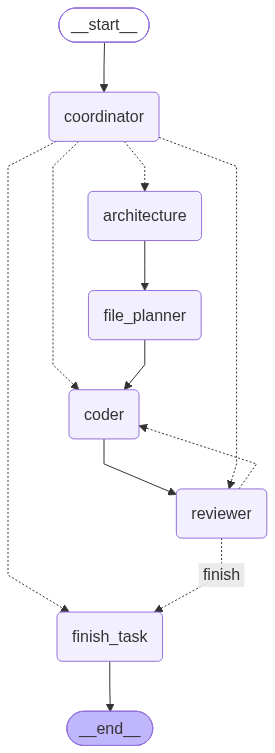

In [11]:
from IPython.display import Image, display


display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [13]:
state = {

    "query":
    "设计Unity背包系统",


    "current_agent":
    "",


    "tasks":
    [],


    "agent_history":
    [],


    "requirements":
    [],


    "context":
    [],


    "architecture":
    "",


    "files":
    [],


    "code":
    "",


    "review":
    {},


    "tools":
    [],


    "tokens":
    0,


    "repair_count":
    0

}

In [14]:
result = app.invoke(
    state
)


result

[Coordinator]任务规划:['architecture']
[Router]任务队列:['architecture']
[Architecture Agent]开始执行
[File Planner Agent]开始执行
[File Planner Agent]生成文件:5个
[Coder Agent]开始多文件生成
[File Manager]写入完成:generated/InventoryData.cs
[Coder Agent]生成完成:generated/InventoryData.cs
[File Manager]写入完成:generated/InventoryManager.cs
[Coder Agent]生成完成:generated/InventoryManager.cs
[File Manager]写入完成:generated/InventoryPanel.cs
[Coder Agent]生成完成:generated/InventoryPanel.cs
[File Manager]写入完成:generated/EventBus.cs
[Coder Agent]生成完成:generated/EventBus.cs
[File Manager]写入完成:generated/IInventoryPersistence.cs
[Coder Agent]生成完成:generated/IInventoryPersistence.cs
[Reviewer Agent]开始执行
[Reviewer Agent]评分:65
[Review Router]评分:65,修复次数:0
[Coder Agent]开始多文件生成
[File Manager]写入完成:generated/InventoryData.cs
[Coder Agent]生成完成:generated/InventoryData.cs
[File Manager]写入完成:generated/InventoryManager.cs
[Coder Agent]生成完成:generated/InventoryManager.cs
[File Manager]写入完成:generated/InventoryPanel.cs
[Coder Agent]生成完成:generated/InventoryPan

KeyboardInterrupt: 

In [16]:
from agents.repair import RepairAgent


repair = RepairAgent()


repair_result = repair.run(
{
    "tools":[
        {
            "tool":
            "file_manager",

            "path":
            "generated/InventoryManager.cs"
        }
    ],

    "review":
    {
        "issues":
        [
            "RemoveItem方法索引异常"
        ]
    },

    "repair_count":0,

    "agent_history":[]
}
)


repair_result

[Repair Agent]开始执行
[File Manager]写入完成:generated/InventoryManager.cs
[Repair Agent]修复完成:generated/InventoryManager.cs


{'code': 'using System;\nusing System.Collections.Generic;\nusing UnityEngine;\n\n/// <summary>\n/// 背包物品数据类\n/// </summary>\n[Serializable]\npublic class InventoryItem\n{\n    public string ItemId;\n    public string ItemName;\n    public int MaxStackCount = 99;\n    public int CurrentCount;\n    public int SlotIndex = -1;\n    public bool IsStackable = true;\n    public Dictionary<string, object> CustomProperties = new Dictionary<string, object>();\n\n    public InventoryItem Clone()\n    {\n        InventoryItem clone = new InventoryItem\n        {\n            ItemId = this.ItemId,\n            ItemName = this.ItemName,\n            MaxStackCount = this.MaxStackCount,\n            CurrentCount = this.CurrentCount,\n            SlotIndex = this.SlotIndex,\n            IsStackable = this.IsStackable,\n            CustomProperties = new Dictionary<string, object>(this.CustomProperties)\n        };\n        return clone;\n    }\n}\n\n/// <summary>\n/// 背包操作结果枚举\n/// </summary>\npublic 

In [30]:
import importlib

import memory.state
import agents.repair
import workflow.graph


importlib.reload(
    memory.state
)


importlib.reload(
    agents.repair
)


importlib.reload(
    workflow.graph
)

<module 'workflow.graph' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\workflow\\graph.py'>

In [31]:
from workflow.graph import AgentWorkflow


workflow = AgentWorkflow()

app = workflow.compile()

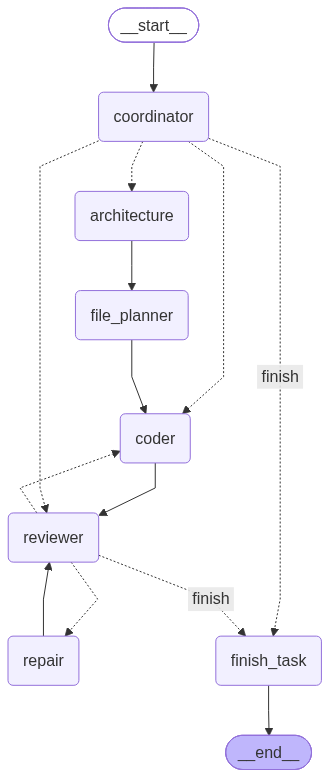

In [32]:
from IPython.display import Image,display


display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [33]:
from agents.repair import RepairAgent


repair_agent = RepairAgent()


test_state = {

    "tools":[
        {
            "tool":
            "file_manager",

            "path":
            "generated/InventoryManager.cs"
        }
    ],


    "review":
    {
        "score":60,

        "issues":[
            "RemoveItem方法存在索引越界风险"
        ]
    },


    "repair_count":0,

    "agent_history":[]

}


result = repair_agent.run(
    test_state
)


result

[Repair Agent]开始执行
[File Manager]写入完成:generated/InventoryManager.cs
[Repair Agent]修复完成:generated/InventoryManager.cs


{'code': 'using System;\nusing System.Collections.Generic;\nusing UnityEngine;\n\n/// <summary>\n/// 背包物品数据类\n/// </summary>\n[Serializable]\npublic class InventoryItem\n{\n    public string ItemId;\n    public string ItemName;\n    public int MaxStackCount = 99;\n    public int CurrentCount;\n    public int SlotIndex = -1;\n    public bool IsStackable = true;\n    public Dictionary<string, object> CustomProperties = new Dictionary<string, object>();\n\n    public InventoryItem Clone()\n    {\n        InventoryItem clone = new InventoryItem\n        {\n            ItemId = this.ItemId,\n            ItemName = this.ItemName,\n            MaxStackCount = this.MaxStackCount,\n            CurrentCount = this.CurrentCount,\n            SlotIndex = this.SlotIndex,\n            IsStackable = this.IsStackable,\n            CustomProperties = new Dictionary<string, object>(this.CustomProperties)\n        };\n        return clone;\n    }\n}\n\n/// <summary>\n/// 背包操作结果枚举\n/// </summary>\npublic 

In [29]:
# =========================
# Agent初始化
# =========================

from agents.coder import CoderAgent
from agents.reviewer import ReviewerAgent
from agents.repair import RepairAgent


coder = CoderAgent()

reviewer = ReviewerAgent()

repair = RepairAgent()

In [31]:
# =========================
# 测试 Agent State
# =========================

state = {

    "query":
    "设计Unity背包系统，并生成C#代码",


    "current_agent":
    "",


    "tasks":
    [
        "architecture",
        "file_planner",
        "coder",
        "reviewer"
    ],


    "agent_history":
    [],


    "requirements":
    [],


    "context":
    [],


    "architecture":
    """
    背包系统包含:
    数据层
    管理层
    UI层
    事件系统
    """,


    "files":
    [
        {
            "name":
            "InventoryManager.cs",

            "description":
            "负责背包物品管理、增加、删除、查询"
        },

        {
            "name":
            "InventoryData.cs",

            "description":
            "负责背包数据结构定义"
        }
    ],


    "code":
    [],


    "review":
    {},


    "tools":
    [],


    "tokens":
    0,


    "repair_count":
    0
}

In [33]:
code_result = coder.run(state)

code_result

[Coder Agent]开始多文件生成
[File Manager]写入完成:generated/InventoryManager.cs
[Coder Agent]生成完成:generated/InventoryManager.cs
[File Manager]写入完成:generated/InventoryData.cs
[Coder Agent]生成完成:generated/InventoryData.cs


{'current_agent': 'coder',
 'code': [{'file': 'InventoryManager.cs',
   'content': 'using System;\nusing System.Collections.Generic;\nusing UnityEngine;\n\nnamespace Game.Inventory\n{\n    /// <summary>\n    /// 背包物品数据类\n    /// </summary>\n    [Serializable]\n    public class InventoryItem\n    {\n        /// <summary>\n        /// 物品唯一标识\n        /// </summary>\n        public string itemId;\n\n        /// <summary>\n        /// 物品名称\n        /// </summary>\n        public string itemName;\n\n        /// <summary>\n        /// 物品数量\n        /// </summary>\n        public int quantity;\n\n        /// <summary>\n        /// 物品最大堆叠数量\n        /// </summary>\n        public int maxStackSize;\n\n        /// <summary>\n        /// 物品图标路径\n        /// </summary>\n        public string iconPath;\n\n        /// <summary>\n        /// 物品描述\n        /// </summary>\n        public string description;\n\n        /// <summary>\n        /// 物品类型\n        /// </summary>\n        public ItemType item

In [34]:
state.update(
    code_result
)

len(state["code"])


2

In [35]:
review_result = reviewer.run(state)

review_result

[Reviewer Agent]开始执行
[Reviewer Agent]评分:65


{'current_agent': 'reviewer',
 'review': {'score': 65,
  'issues': [{'file': 'InventoryManager.cs',
    'method': 'InventoryItem',
    'problem': 'InventoryItem 类中 itemId 字段在无参构造函数中通过 Guid.NewGuid().ToString() 初始化，但在带参构造函数中同样初始化，导致每次创建新对象都会生成新ID，但未提供从外部设置ID的途径，可能导致序列化或数据恢复时ID不一致。',
    'suggestion': '建议在带参构造函数中增加可选参数 itemId，允许外部传入ID，若未传入则自动生成。例如：public InventoryItem(string name, int maxStack = 99, ItemType type = ItemType.Common, ItemRarity rarity = ItemRarity.Normal, string itemId = null) { this.itemId = itemId ?? Guid.NewGuid().ToString(); ... }'},
   {'file': 'InventoryManager.cs',
    'method': 'Items',
    'problem': 'Items 属性返回 _items.AsReadOnly()，每次调用都会创建一个新的 ReadOnlyCollection 包装对象，造成不必要的内存分配。',
    'suggestion': '建议将 _items 声明为 List<InventoryItem>，并直接返回 _items 的只读视图，或者缓存 AsReadOnly() 的结果。例如：private ReadOnlyCollection<InventoryItem> _readOnlyItems; 在 InitializeInventory 中初始化 _readOnlyItems = _items.AsReadOnly(); 然后返回 _readOnlyItems。'},
   {'file': 'InventoryManager.cs',
    'me

In [36]:
code_result = coder.run(state)

state.update(code_result)

print(len(state["code"]))

[Coder Agent]开始多文件生成
[File Manager]写入完成:generated/InventoryManager.cs
[Coder Agent]生成完成:generated/InventoryManager.cs
[File Manager]写入完成:generated/InventoryData.cs
[Coder Agent]生成完成:generated/InventoryData.cs
2


In [37]:
review_result = reviewer.run(state)

review_result["review"]

[Reviewer Agent]开始执行
[Reviewer Agent]评分:75


{'score': 75,
 'issues': [{'file': 'InventoryManager.cs',
   'method': 'AddItem',
   'problem': '在遍历 _items 时，如果 itemId 匹配且 quantity < maxStackSize，会修改 item.quantity，但未检查 item 是否为 null。虽然当前代码中 _items 的元素不会为 null，但后续维护可能引入 null 引用风险。',
   'suggestion': '在 foreach 循环内部增加 null 检查：if (item == null) continue;'},
  {'file': 'InventoryManager.cs',
   'method': 'RemoveItem',
   'problem': '在 for 循环中直接修改 _items[i].quantity 并可能 RemoveAt，但未对 _items[i] 进行 null 检查，存在潜在空引用风险。',
   'suggestion': '在循环内增加 if (_items[i] == null) continue; 跳过空元素。'},
  {'file': 'InventoryManager.cs',
   'method': 'GetItemQuantity',
   'problem': '遍历 _items 时未对 item 进行 null 检查，若列表中出现 null 元素会引发 NullReferenceException。',
   'suggestion': '在 foreach 循环内增加 if (item == null) continue;'},
  {'file': 'InventoryManager.cs',
   'method': 'HasItem',
   'problem': '遍历 _items 时未对 item 进行 null 检查，存在空引用风险。',
   'suggestion': '在 foreach 循环内增加 if (item == null) continue;'},
  {'file': 'InventoryManager.cs',
   'method': 'GetItemsById',
 

In [6]:
import importlib

import memory.state
import workflow.graph


importlib.reload(memory.state)
importlib.reload(workflow.graph)
import workflow.router

print(workflow.router.__file__)

print(dir(workflow.router))

D:\Anaconda\Project\AI-Coding-Agent\agent-learning\day05\workflow\router.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'router']


In [7]:
from workflow.graph import AgentWorkflow


workflow = AgentWorkflow()

app = workflow.compile()

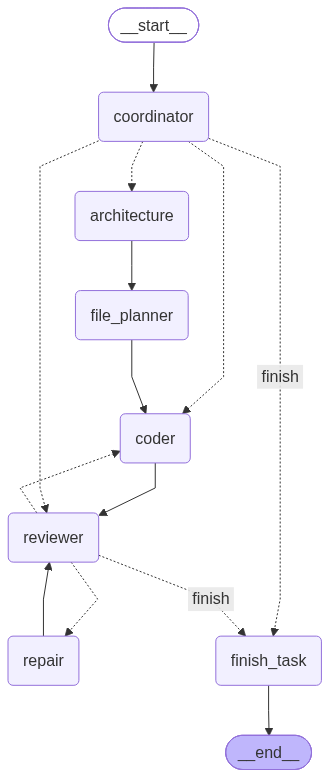

In [8]:
from IPython.display import Image,display
display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [9]:
# =========================
# 测试 Agent State
# =========================

state = {

    "query":
    "设计Unity背包系统，并生成C#代码",


    "current_agent":
    "",


    "tasks":
    [
        "architecture",
        "file_planner",
        "coder",
        "reviewer"
    ],


    "agent_history":
    [],


    "requirements":
    [],


    "context":
    [],


    "architecture":
    """
    背包系统包含:
    数据层
    管理层
    UI层
    事件系统
    """,


    "files":
    [
        {
            "name":
            "InventoryManager.cs",

            "description":
            "负责背包物品管理、增加、删除、查询"
        },

        {
            "name":
            "InventoryData.cs",

            "description":
            "负责背包数据结构定义"
        }
    ],


    "code":
    [],


    "review":
    {},


    "tools":
    [],


    "tokens":
    0,


    "repair_count":
    0
}

In [11]:
# 完整测试
result = app.invoke(state)

[Coordinator]任务规划:['architecture', 'coder', 'reviewer']
[Router]任务队列:['architecture', 'coder', 'reviewer']
[Architecture Agent]开始执行
[File Planner Agent]开始执行
[File Planner Agent]生成文件:0个
[Coder Agent]开始多文件生成
[Reviewer Agent]开始执行
[Reviewer Agent]评分:0
[Review Router]评分:0,通过:False,修复次数:0
[Review Router]进入代码修复
[Repair Agent]开始执行
[Repair Agent]读取文件:generated/未提供代码文件
[Repair Agent]文件内容为空，取消修复
[Reviewer Agent]开始执行
[Reviewer Agent]评分:100
[Review Router]评分:100,通过:True,修复次数:0
[Review Router]代码审核通过
[Finish Task]完成:reviewer
[Finish Task]剩余任务:['architecture', 'coder']


In [13]:
import importlib

import agents.coordinator
import agents.file_planner

importlib.reload(
    agents.coordinator
)

importlib.reload(
    agents.file_planner
)

<module 'agents.file_planner' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\agents\\file_planner.py'>

In [14]:
import workflow.graph

importlib.reload(
    workflow.graph
)

<module 'workflow.graph' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\workflow\\graph.py'>

In [8]:
from workflow.graph import AgentWorkflow

workflow = AgentWorkflow()

app = workflow.compile()

In [16]:
state = {

    "query":
    "设计Unity背包系统",

    "current_agent":
    "",

    "tasks":
    [],

    "agent_history":
    [],

    "requirements":
    [],

    "context":
    [],

    "architecture":
    "",

    "files":
    [],

    "code":
    [],

    "review":
    {},

    "tools":
    [],

    "tokens":
    0,

    "repair_count":
    0
}

In [17]:
# 完整测试
result = app.invoke(state)

[Coordinator]任务规划:['architecture', 'file_planner', 'coder', 'reviewer']
[Router]任务队列:['architecture', 'file_planner', 'coder', 'reviewer']
[Architecture Agent]开始执行
[File Planner Agent]开始执行
[File Planner Agent]架构长度:18909
[File Planner Agent]模型返回:
```json
{
    "files": [
        {
            "name": "BagSystem.cs",
            "description": "背包系统核心单例，负责物品的添加、移除、移动、使用等核心逻辑，管理多背包数据，维护物品配置缓存，并对外发布物品变更事件。"
        },
        {
            "name": "BagData.cs",
            "description": "背包数据模型定义，包含BagData和ItemSlotData可序列化类，定义背包容量、槽位列表、物品堆叠映射等数据结构，提供槽位初始化和清空等基础操作。"
        },
        {
            "name": "BagController.cs",
            "description": "背包控制器，桥接BagSystem与BagView，处理UI交互逻辑（拖拽、使用、排序），订阅并响应核心层事件，驱动视图层刷新。"
        },
        {
            "name": "BagView.cs",
            "description": "背包视图层组件，负责UI显示与交互，管理SlotView列表，提供创建槽位、刷新单个/全部槽位的方法，并持有控制器引用以转发用户操作。"
        },
        {
            "name": "EventBus.cs",
            "description": "全局事件总线静态类，提供事件订阅、取消订阅和发布功能，用于解耦核心层与控制器/视

In [16]:
import importlib

import agents.repair
import workflow.graph

importlib.reload(
    agents.repair
)

importlib.reload(
    workflow.graph
)

<module 'workflow.graph' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\workflow\\graph.py'>

In [17]:
from workflow.graph import AgentWorkflow

workflow = AgentWorkflow()

app = workflow.compile()

In [14]:
state = {
    "query":"设计一个Unity背包系统",
    "current_agent":"",
    "tasks":[],
    "agent_history":[],
    "requirements":[],
    "context":[],
    "architecture":"",
    "files":[],
    "code":[],
    "review":{},
    "tools":[],
    "tokens":0,
    "repair_count":0
}

In [18]:
# 完整测试 
result = app.invoke(state)

[Coordinator]任务规划:['architecture', 'file_planner', 'coder', 'reviewer']
[Router]任务队列:['architecture', 'file_planner', 'coder', 'reviewer']
[Architecture Agent]开始执行
[File Planner Agent]开始执行
[File Planner Agent]架构长度:9437
[File Planner Agent]模型返回:
```json
{
    "files": [
        {
            "name": "BagModels.cs",
            "description": "数据层模型定义：包含ItemData、SlotData、BagData三个核心数据类，以及物品类型枚举和背包类型枚举，为整个背包系统提供数据结构基础。"
        },
        {
            "name": "BagService.cs",
            "description": "服务层核心逻辑：实现IItemService和IBagService接口，负责物品的增删改查、堆叠管理、背包容量控制、物品移动等核心业务逻辑，并通过事件系统通知UI更新。"
        },
        {
            "name": "BagManager.cs",
            "description": "控制层总控：作为MonoBehaviour组件挂载在场景中，负责初始化服务、管理背包生命周期、处理拖拽和排序操作，并作为ServiceLocator向视图层提供访问入口。"
        },
        {
            "name": "BagView.cs",
            "description": "视图层UI控制：负责背包界面的显示与刷新，管理SlotView对象池，监听服务层事件更新UI，处理拖拽交互和Tooltip显示，实现打开/关闭动画和分页切换。"
        },
        {
            "name": "SlotView.cs",
            "

In [7]:
import prompts.reviewer_prompt

print(
    prompts.reviewer_prompt.__file__
)

D:\Anaconda\Project\AI-Coding-Agent\agent-learning\day05\prompts\reviewer_prompt.py


In [23]:
state = {

    "query":
    "设计一个Unity背包系统",

    "current_agent":
    "",

    "tasks":
    [],

    "agent_history":
    [],

    "requirements":
    [],

    "context":
    [],

    "architecture":
    "",

    "files":
    [],

    "code":
    [],

    "review":
    {},

    "review_history":
    [],

    "code_check_result":
    {},

    "tools":
    [],

    "tokens":
    0,

    "repair_count":
    0,

    "repair_status":
    "",

    "repair_result":
    {},

    "repair_history":
    []
}

In [32]:
import importlib
import agents.repair

importlib.reload(
    agents.repair
)

<module 'agents.repair' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\agents\\repair.py'>

In [33]:
from agents.repair import RepairAgent


agent = RepairAgent()


print(
    agent.normalize_file_path(
        "BagData.cs"
    )
)


print(
    agent.normalize_file_path(
        "generated/BagData.cs"
    )
)


print(
    agent.normalize_file_path(
        "./generated/BagData.cs"
    )
)

generated/BagData.cs
generated/BagData.cs
generated/BagData.cs


In [1]:
import importlib
import agents.file_planner
import workflow.graph

importlib.reload(agents.file_planner)
importlib.reload(workflow.graph)

<module 'workflow.graph' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\workflow\\graph.py'>

In [2]:
import importlib

import prompts.architecture_prompt
import prompts.file_planner_prompt
import prompts.reviewer_prompt

import agents.architecture
import agents.file_planner
import agents.reviewer

import workflow.graph

importlib.reload(prompts.architecture_prompt)
importlib.reload(prompts.file_planner_prompt)
importlib.reload(prompts.reviewer_prompt)

importlib.reload(agents.architecture)
importlib.reload(agents.file_planner)
importlib.reload(agents.reviewer)

importlib.reload(workflow.graph)

<module 'workflow.graph' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\workflow\\graph.py'>

In [14]:
import sys
import importlib

for module in [
    "agents.architecture",
    "workflow.graph"
]:
    if module in sys.modules:
        importlib.reload(
            sys.modules[module]
        )

print("reload完成")

reload完成


In [30]:
import importlib

import agents.architecture
import workflow.graph

importlib.reload(
    agents.architecture
)

importlib.reload(
    workflow.graph
)

<module 'workflow.graph' from 'D:\\Anaconda\\Project\\AI-Coding-Agent\\agent-learning\\day05\\workflow\\graph.py'>

In [31]:
from workflow.graph import AgentWorkflow

workflow = AgentWorkflow()

app = workflow.compile()

print("Workflow编译完成")

Workflow编译完成


In [27]:
state = {
    "query": "设计一个Unity背包系统",
    "current_agent": "",
    "tasks": [],
    "architecture": "",
    "files": [],
    "code": [],
    "review": {},
    "repair_count": 0,
    "repair_status": "",
    "repair_result": {},
    "repair_history": []
}

In [32]:
result = app.invoke(
    state
)

[Coordinator]任务规划:['architecture', 'file_planner', 'coder', 'code_checker', 'reviewer']
[Router]任务队列:['architecture', 'file_planner', 'coder', 'code_checker', 'reviewer']
[Architecture Agent]开始执行
[DeepSeek]请求模型，第1次
[DeepSeek]调用成功
[File Planner Agent]开始执行


ValueError: Invalid format specifier '"xxx.cs",
            "description":"文件职责"
        ' for object of type 'str'

In [29]:
from llm.deepseek import DeepSeekLLM

llm = DeepSeekLLM()

result = llm.invoke(
    "你好"
)

print(type(result))
print(result)


[DeepSeek]请求模型，第1次
[DeepSeek]调用成功
<class 'str'>
你好！很高兴见到你，有什么我可以帮你的吗？无论是问题、聊天还是需要建议，我都在这儿。😊
